In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Mall_Customers.csv')

display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.shape

(200, 5)

In [5]:
df.drop(['CustomerID', 'Gender'], axis = 1, inplace = True)

In [6]:
df.head(3)

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6


<Axes: ylabel='Age'>

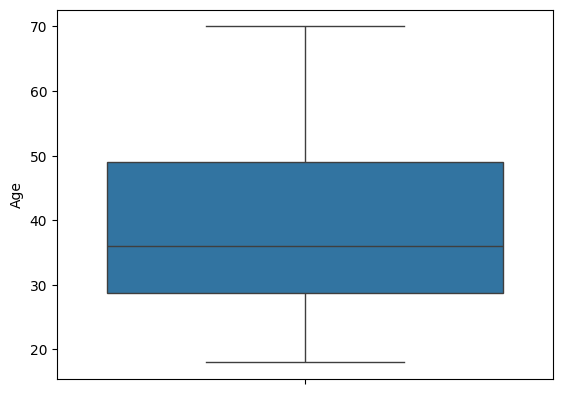

In [7]:
sns.boxplot(df['Age'])

<Axes: ylabel='Annual Income (k$)'>

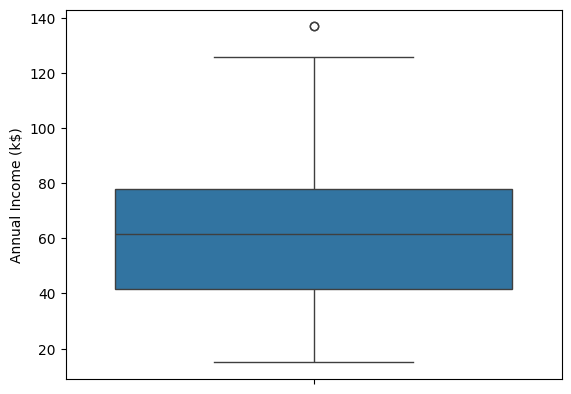

In [8]:
sns.boxplot(df['Annual Income (k$)'])

<Axes: ylabel='Spending Score (1-100)'>

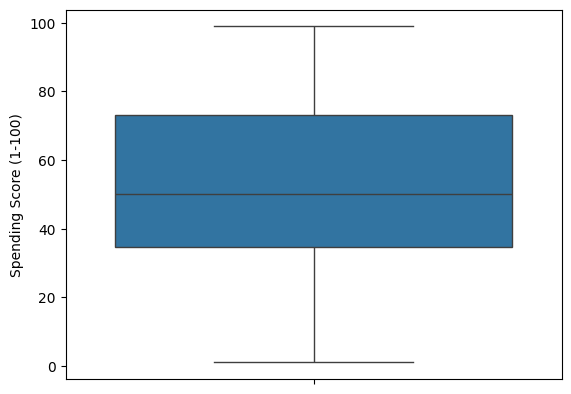

In [9]:
sns.boxplot(df["Spending Score (1-100)"])

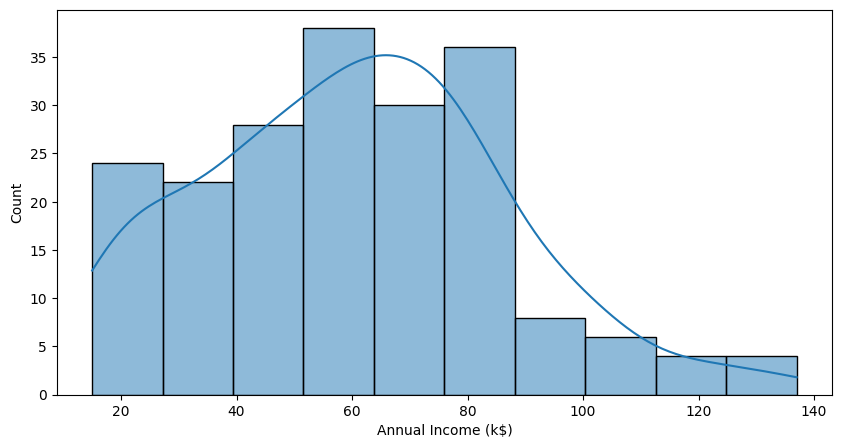

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['Annual Income (k$)'], kde = True)
plt.show()

In [11]:
df.iloc[ 3:5, : ]

,Age,Annual Income (k$),Spending Score (1-100)
3,23,16,77
4,31,17,40


In [12]:
x = df.iloc[:, :].values

In [13]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
wcss = []
for i in range(1,12):
  kmeans = KMeans(n_clusters = i, random_state = 42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

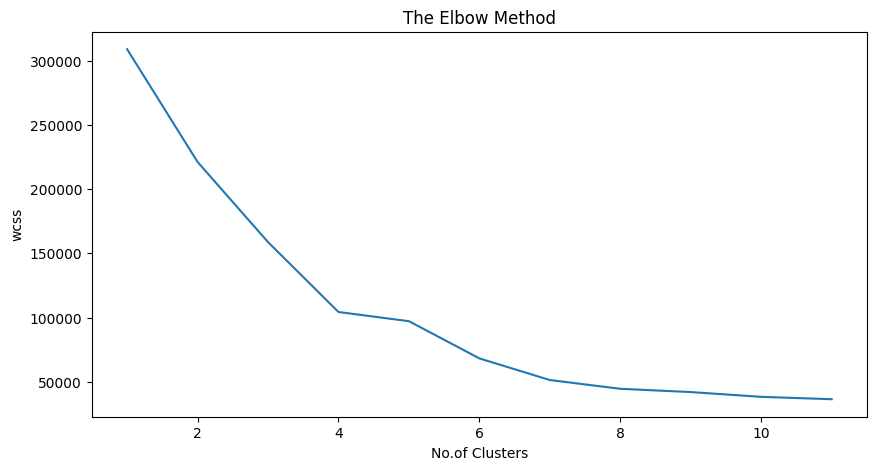

In [14]:
plt.figure(figsize=(10,5))
plt.plot(range(1,12), wcss)
plt.title("The Elbow Method")
plt.xlabel("No.of Clusters")
plt.ylabel("wcss")
plt.show()

As per Elbow method , we got the two clusters WCSS(within clusters sum of squares) values uniform , the cluster are 4 and 5, i choose the least clusters is 4.

# Model Building

In [15]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 4, random_state = 42)
model.fit(x)

KMeans(n_clusters=4, random_state=42)

In [16]:
label = model.labels_

In [17]:
label

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [18]:
from collections import Counter
Counter(label)

Counter({np.int32(2): 28, np.int32(0): 95, np.int32(1): 39, np.int32(3): 38})

In [19]:
df.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [20]:
new_point = [[23, 18, 50]]

In [21]:
model.predict(new_point)

array([2], dtype=int32)

In [22]:
df['Labels'] = label
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Labels
0,19,15,39,2
1,21,15,81,2
2,20,16,6,0
3,23,16,77,2
4,31,17,40,0


In [23]:
model.cluster_centers_

array([[44.89473684, 48.70526316, 42.63157895],
       [32.69230769, 86.53846154, 82.12820513],
       [24.82142857, 28.71428571, 74.25      ],
       [40.39473684, 87.        , 18.63157895]])

### Visualizing the Clusters

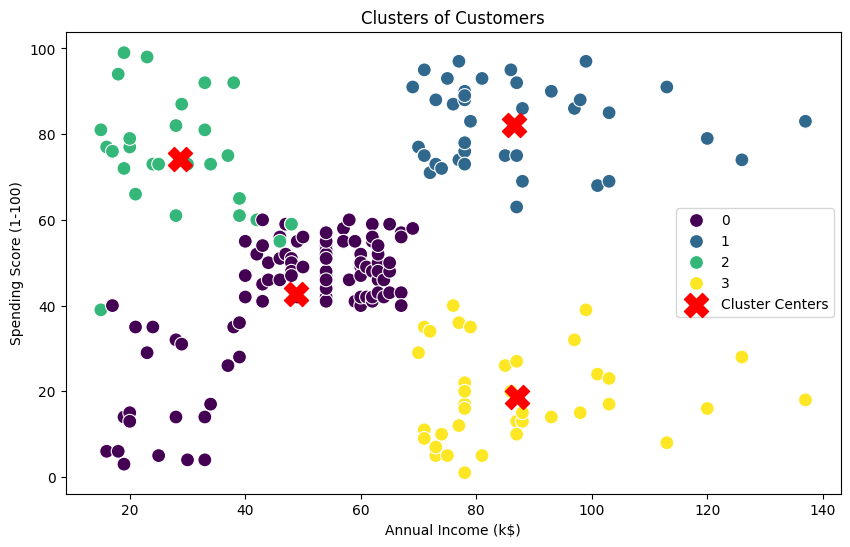

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Labels', data=df, palette='viridis', s=100)
plt.scatter(model.cluster_centers_[:, 1], model.cluster_centers_[:, 2], s=300, c='red', marker='X', label='Cluster Centers')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### Naming the Clusters
    0: Average Spenders
    1: High Income, High Spenders
    2: Young, Low Income, High Spenders
    3: High Income, Low Spenders

In [25]:
# Define a dictionary to map numerical labels to descriptive names
cluster_names = {
    0: "Average Spenders",
    1: "High Income, High Spenders",
    2: "Young, Low Income, High Spenders",
    3: "High Income, Low Spenders"
}

# Apply the mapping to the 'Labels' column
df['Cluster Name'] = df['Labels'].map(cluster_names)

# Display the DataFrame with the new 'Cluster Name' column
display(df.head())

,Age,Annual Income (k$),Spending Score (1-100),Labels,Cluster Name
0,19,15,39,2,"Young, Low Income, High Spenders"
1,21,15,81,2,"Young, Low Income, High Spenders"
2,20,16,6,0,Average Spenders
3,23,16,77,2,"Young, Low Income, High Spenders"
4,31,17,40,0,Average Spenders


In [26]:
predicted_label_array = model.predict([[26,30,56]])
predicted_label = predicted_label_array[0]

predicted_cluster_name = cluster_names[predicted_label]

print(f"The new point belongs to Cluster: {predicted_label} (\"{predicted_cluster_name}\")")

The new point belongs to Cluster: 2 ("Young, Low Income, High Spenders")
